# 02 - Medical Dictionary Creation

In this notebook, we construct the **Semantic Concept Matrix ($T$)** using a robust, data-driven, and clinically validated pipeline. This matrix serves as the semantic ground truth required for the unsupervised concept discovery and valuation of the Sparse Autoencoder (SAE) latent features.

In [43]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    requirements_path = "/content/drive/MyDrive/xai-project5/requirements.txt"
else:
    requirements_path = "./../../requirements.txt"

!pip install -r "{requirements_path}"

In [44]:
import os

if IN_COLAB:
    from google.colab import userdata

    # Reading secrets from Google Colab
    UMLS_API_KEY = userdata.get('UMLS_API_KEY')
    HF_TOKEN = userdata.get('HF_TOKEN')
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

    save_dir = '/content/drive/MyDrive/xai-project5/results/02_dictionary_creation'
else:
    from dotenv import load_dotenv

    # Load from .env file in the project folder
    load_dotenv()
    UMLS_API_KEY = os.getenv('UMLS_API_KEY')
    HF_TOKEN = os.getenv('HF_TOKEN')
    GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
    
    save_dir = os.path.abspath(os.path.join('..', 'results', '02_dictionary_creation'))

os.makedirs(save_dir, exist_ok=True)
print(f"Save directory configured at: {save_dir}")

Save directory configured at: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/02_dictionary_creation


In [60]:
import re
import pandas as pd
from collections import Counter
from datasets import load_dataset
import requests
import json
import time
import gc
import torch
from google import genai
from google.genai import types
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import numpy as np
import torch.nn.functional as F
from tqdm.auto import tqdm
import open_clip


## 1. Candidate Concept Extraction from Open-I

We derive the initial vocabulary directly from the `Problems` metadata of the **Open-I chest X-ray dataset**. Each record may contain multiple indexed terms; we split, normalize, deduplicate, and count these terms to obtain dataset-specific candidate concepts.

This stage produces a broad inventory that can include findings, anatomical structures, devices, descriptive terms, and non-clinical metadata. It is therefore an initial candidate pool—not yet a validated clinical dictionary.

In [25]:
DATASET_ID = "ykumards/open-i"
EXCLUDED_ENTRIES = {"", "normal", "no indexing"}

# Load the Open-I split and access only its textual metadata. Images are not used in this dictionary-extraction step.
print(f"Loading '{DATASET_ID}' metadata...")
dataset_meta = load_dataset(DATASET_ID, split="train")

Loading 'ykumards/open-i' metadata...


In [26]:
def normalize_term(term):
    """Normalize formatting without changing the clinical meaning."""

    term = str(term).strip().lower()
    term = re.sub(r"\s+", " ", term)
    return term

concept_counts = Counter()
raw_examples = {}

for problems in dataset_meta["Problems"]:
    if problems is None:
        continue

    # In Open-I, semicolons separate indexed concepts.
    # We don't split on commas: e.g. "Aorta, Thoracic" is one concept
    for raw_term in str(problems).split(";"):
        concept = normalize_term(raw_term)

        if concept in EXCLUDED_ENTRIES:
            continue

        concept_counts[concept] += 1
        raw_examples.setdefault(concept, raw_term.strip())

candidate_concepts = (
    pd.DataFrame(
        [
            {
                "candidate_term": concept,
                "frequency": count,
                "example_raw_term": raw_examples[concept],
            }
            for concept, count in concept_counts.items()
        ]
    )
    .sort_values(["frequency", "candidate_term"], ascending=[False, True])
    .reset_index(drop=True)
)

# This remains the complete, dataset-derived candidate pool.
dynamic_labels = candidate_concepts["candidate_term"].tolist()

print(f"\nUnique candidate concepts extracted: {len(dynamic_labels)}")
print(f"Total non-empty concept occurrences: {sum(concept_counts.values())}")

print("\nTop 50 candidates by frequency:")
display(candidate_concepts.head(50))


Unique candidate concepts extracted: 116
Total non-empty concept occurrences: 6475

Top 50 candidates by frequency:


,candidate_term,frequency,example_raw_term
0,lung,553,Lung
1,opacity,509,Opacity
2,cardiomegaly,345,Cardiomegaly
3,calcinosis,332,Calcinosis
4,pulmonary atelectasis,330,Pulmonary Atelectasis
5,calcified granuloma,276,Calcified Granuloma
6,thoracic vertebrae,257,Thoracic Vertebrae
7,cicatrix,196,Cicatrix
8,spine,174,Spine
9,markings,167,Markings


In [27]:
# Optional: preserve this intermediate audit artifact.
candidate_concepts.to_csv(
    os.path.join(save_dir, "openi_concepts_raw.csv"),
    index=False,
)

## 2. Clinical Filtration & Domain Alignment

The raw candidate concepts extracted from the Open-I `Problems` field are highly noisy. They contain anatomical structures and pathological entities, but also medical devices, surgical materials, and technical image-quality annotations.

We must rigorously filter this vocabulary, because in the final evaluation we will use a large language model (MedGemma) to evaluate semantic alignment exclusively against the clinical `findings` and `impression` sections of radiology reports, evaluating non-clinical concepts (e.g., "Surgical Instruments") would artificially inflate our `Unaligned` and `Uncertain` metrics.

#### Pipeline Actions:
1. **The Exclusion Filter:** We systematically drop hardware, procedures, and image quality descriptors.
2. **Domain Alignment:** Ambiguous terms inherent to the chest X-ray domain (e.g., "Mass", "Opacity") are too broad for a universal ontology like UMLS. We programmatically map these to their precise thoracic/pulmonary counterparts (e.g., "Pulmonary Mass", "Lung Opacity") *before* querying the UMLS API. This guarantees deterministic CUI retrieval and eliminates the need for brittle error-handling loops.

In [28]:
# Load the raw candidate concepts
print("Loading raw concepts from Step 1...")
raw_csv_path = os.path.join(save_dir, "openi_concepts_raw.csv")
candidate_concepts = pd.read_csv(raw_csv_path)

Loading raw concepts from Step 1...


In [29]:
# Devices, surgical hardware, procedures, and technical/image-quality artifacts. Not clinical anatomical/pathological findings.
EXCLUSION_FILTER = {
    # Devices / hardware
    "catheters, indwelling",
    "surgical instruments",
    "implanted medical device",
    "medical device",
    "tube, inserted",
    "stents",
    "sutures",
    "breast implants",
    "foreign bodies",

    # Procedures / post-surgical states
    "mastectomy",
    "pneumonectomy",
    "spinal fusion",
    "colonic interposition",

    # Imaging agents / technical artifacts
    "contrast media",
    "technical quality of image unsatisfactory",
}

# This contextualizes ambiguous Open-I shorthand to strict pulmonary/thoracic terminology
DOMAIN_ALIGNMENT_MAP = {
    # ---- Ambiguous Pathological Descriptors ----
    "opacity":          "lung opacity",
    "density":          "lung density",
    "markings":         "bronchovascular markings",
    "infiltrate":       "pulmonary infiltrate",
    "consolidation":    "pulmonary consolidation",
    "airspace disease": "pulmonary airspace disease",
    "thickening":       "pleural thickening",
    "lucency":          "pulmonary lucency",
    "volume loss":      "lung volume loss",
    "cavitation":       "pulmonary cavitation",
    "fibrosis":         "pulmonary fibrosis",
    "cicatrix":         "pulmonary cicatrix",
    "cysts":            "pulmonary cyst",

    # ---- Focal Lesions ----
    "mass":             "pulmonary mass",
    "nodule":           "pulmonary nodule",
    "granuloma":        "pulmonary granuloma",
    "blister":          "pulmonary bleb",

    # ---- Anatomical Positioning & Structural ----
    "shift":            "mediastinal shift",
    "sulcus":           "costophrenic sulcus",
    "cardiac shadow":   "cardiac silhouette",
    "deformity":        "thoracic skeletal deformity",
    "sclerosis":        "bone sclerosis", 
    "fractures, bone":  "bone fracture",
    "blood vessels":    "pulmonary blood vessels",
    "diaphragm":        "thoracic diaphragm"
}

print("Applying Clinical Filtration and Domain Alignment...")

# Initialize the clean list for Step 3
filtered_rows = []
dropped_terms = []

for _, row in candidate_concepts.iterrows():
    raw_term = row['candidate_term']
    
    # 1. Apply Exclusion Filter
    if raw_term in EXCLUSION_FILTER:
        dropped_terms.append(raw_term)
        continue
        
    # 2. Apply Domain Alignment
    # If the term is in our map, use the specific context; otherwise, keep the original
    aligned_term = DOMAIN_ALIGNMENT_MAP.get(raw_term, raw_term)
    
    filtered_rows.append({
        "aligned_term": aligned_term,
        "frequency": row['frequency'],
        "example_raw_term": row['example_raw_term']
    })

# Convert to DataFrame
clinical_concepts_df = pd.DataFrame(filtered_rows)

# Group by the aligned terms to merge duplicates and sum their frequencies
final_df = clinical_concepts_df.groupby('aligned_term').agg({
    'frequency': 'sum',
    'example_raw_term': 'first'  # Keep the first raw term as an example
}).reset_index().sort_values(by='frequency', ascending=False)

print(f"Original concepts extracted: {len(candidate_concepts)}")
print(f"Concepts dropped (Hardware/Artifacts): {len(dropped_terms)}")
print(f"Final validated clinical concepts ready for UMLS: {len(final_df)}")

print("\nTop 10 validated clinical concepts:")
display(final_df.head(10))

Applying Clinical Filtration and Domain Alignment...
Original concepts extracted: 116
Concepts dropped (Hardware/Artifacts): 15
Final validated clinical concepts ready for UMLS: 100

Top 10 validated clinical concepts:


,aligned_term,frequency,example_raw_term
47,lung,553,Lung
50,lung opacity,509,Opacity
19,cardiomegaly,345,Cardiomegaly
17,calcinosis,332,Calcinosis
69,pulmonary atelectasis,330,Pulmonary Atelectasis
16,calcified granuloma,276,Calcified Granuloma
95,thoracic vertebrae,257,Thoracic Vertebrae
73,pulmonary cicatrix,196,Cicatrix
90,spine,174,Spine
14,bronchovascular markings,167,Markings


In [30]:
# Save the finalized, clean dictionary to a new CSV
filtered_csv_path = os.path.join(save_dir, "openi_concepts_filtered_aligned.csv")
final_df.to_csv(filtered_csv_path, index=False)
print(f"\nFiltered clinical concepts successfully saved to: {filtered_csv_path}")


Filtered clinical concepts successfully saved to: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/02_dictionary_creation/openi_concepts_filtered_aligned.csv


## 3. Ontological Grounding (UMLS API Integration)

To anchor our unsupervised concepts to certified medical knowledge, each validated term is cross-referenced with the **Unified Medical Language System (UMLS)** Terminology Services.

Because we pre-aligned the domains in the previous step (e.g., mapping "mass" to "pulmonary mass"), we can confidently query the API for exact matches. 

#### Pipeline Actions:
1. **CUI Retrieval:** Queries the UMLS API to retrieve the official Concept Unique Identifier (CUI) for each aligned term.
2. **Synonym Extraction:** Extracts certified synonyms from standardized clinical ontologies (strictly filtering for **SNOMED CT** and **MeSH** to maintain high quality).
3. **State Management:** Implements a robust JSON checkpointing system. If the Google Colab environment disconnects or the API times out, the pipeline will resume exactly where it left off without duplicating network requests.

In [31]:
def get_umls_cui(term: str, api_key: str) -> str:
    """Queries UMLS for the exact Concept Unique Identifier (CUI)."""
    endpoint = f"{BASE_URL}/search/current"
    params = {
        "string": term,
        "apiKey": api_key,
        "searchType": "exact"
    }
    try:
        response = requests.get(endpoint, params=params, timeout=10)
        if response.status_code == 200:
            results = response.json().get('result', {}).get('results', [])
            if results:
                return results[0]['ui']
    except requests.exceptions.RequestException as e:
        print(f"  [Error] CUI Network exception for '{term}': {e}")
    return None

def get_umls_synonyms(cui: str, api_key: str):
    """Retrieves SNOMED CT and MeSH synonyms for a given CUI."""
    endpoint = f"{BASE_URL}/content/current/CUI/{cui}/atoms"
    params = {
        "apiKey": api_key,
        "language": "ENG",
        "sabs": "SNOMEDCT_US,MSH" # Force high-quality vocabularies only
    }
    synonyms = set()
    try:
        response = requests.get(endpoint, params=params, timeout=10)
        if response.status_code == 200:
            results = response.json().get('result', [])
            for item in results:
                name = item.get('name', '')
                # Filter to avoid highly technical codes, brackets, or overly long descriptions
                if name and len(name) < 45 and "[" not in name and "-" not in name:
                    synonyms.add(name.lower())
    except requests.exceptions.RequestException as e:
        print(f"  [Error] Synonym Network exception for CUI '{cui}': {e}")
        
    return list(synonyms)

In [32]:
print("Loading aligned clinical concepts from Step 2...")
filtered_csv_path = os.path.join(save_dir, "openi_concepts_filtered_aligned.csv")
final_df = pd.read_csv(filtered_csv_path)
aligned_terms = final_df['aligned_term'].tolist()

Loading aligned clinical concepts from Step 2...


In [34]:
BASE_URL = "https://uts-ws.nlm.nih.gov/rest"

umls_checkpoint_path = os.path.join(save_dir, 'umls_checkpoint.json')
umls_dictionary = {}

# Resume from checkpoint if it exists
if os.path.exists(umls_checkpoint_path):
    print("Found existing UMLS checkpoint. Resuming...")
    with open(umls_checkpoint_path, 'r', encoding='utf-8') as f:
        umls_dictionary = json.load(f)

print(f"\nStarting UMLS API Queries for {len(aligned_terms)} terms:")

for term in aligned_terms:
    # Check if term is already processed and has a valid list
    if term in umls_dictionary and umls_dictionary[term].get("status") == "ok":
        print(f"  Skipping '{term}', already in checkpoint.")
        continue

    print(f"  Querying: '{term}'")
    cui = get_umls_cui(term, UMLS_API_KEY)
    
    # Always anchor the dictionary with the base term itself
    syns = [term]
    
    if cui:
        retrieved_syns = get_umls_synonyms(cui, UMLS_API_KEY)
        
        # Append unique synonyms to the base term
        for s in retrieved_syns:
            if s not in syns:
                syns.append(s)
                
        print(f"    Found CUI: {cui} -> Retrieved {len(retrieved_syns)} certified synonyms.")
    else:
        print(f"    No exact CUI match. Retaining base term only.")

    # Update state and save
    umls_dictionary[term] = {
        "cui": cui,                    # None if truly not found
        "status": "ok" if cui else "no_cui_match",
        "synonyms": syns
    }
    with open(umls_checkpoint_path, 'w', encoding='utf-8') as f:
        json.dump(umls_dictionary, f, indent=4)
        
    # Brief delay to respect NLM API rate limits and prevent timeouts
    time.sleep(0.2)

print(f"\nStep 3 Complete! UMLS Dictionary successfully grounded and saved to:\n{umls_checkpoint_path}")


Starting UMLS API Queries for 100 terms:
  Querying: 'lung'
    Found CUI: C0024109 -> Retrieved 4 certified synonyms.
  Querying: 'lung opacity'
    Found CUI: C4728208 -> Retrieved 0 certified synonyms.
  Querying: 'cardiomegaly'
    Found CUI: C0018800 -> Retrieved 6 certified synonyms.
  Querying: 'calcinosis'
    Found CUI: C0006663 -> Retrieved 6 certified synonyms.
  Querying: 'pulmonary atelectasis'
    Found CUI: C0004144 -> Retrieved 14 certified synonyms.
  Querying: 'calcified granuloma'
    Found CUI: C0333404 -> Retrieved 1 certified synonyms.
  Querying: 'thoracic vertebrae'
    Found CUI: C0039987 -> Retrieved 5 certified synonyms.
  Querying: 'pulmonary cicatrix'
    No exact CUI match. Retaining base term only.
  Querying: 'spine'
    Found CUI: C0037949 -> Retrieved 11 certified synonyms.
  Querying: 'bronchovascular markings'
    No exact CUI match. Retaining base term only.
  Querying: 'pleural effusion'
    Found CUI: C0032227 -> Retrieved 5 certified synonyms.
 

## 4. LLM Expansion: UMLS-grounded radiological phrase generation

We merge the clinical rigidity of UMLS with the linguistic flexibility of the LLM. For each pathology, we provide the LLM with official synonyms and ask it to generate realistic phrases a radiologist would use in a report.

In [50]:
print(f"Loading grounded concepts from Step 3...")
umls_checkpoint_path = os.path.join(save_dir, 'umls_checkpoint.json')
with open(umls_checkpoint_path, 'r', encoding='utf-8') as f:
    umls_dictionary = json.load(f)

Loading grounded concepts from Step 3...


In [51]:
def normalize_phrase(text: str) -> str:
    """Normalize generated or ontology text for deduplication."""
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip(" -–—•*\"'")

def validate_generated_sentences(sentences, expected_count=5):
    """
    Return exactly five unique, short report fragments.
    A fragment must contain 6–16 words and at most 140 characters.
    """
    valid_sentences = []
    seen = set()

    for sentence in sentences:
        cleaned = normalize_phrase(sentence)
        word_count = len(cleaned.split())

        if (cleaned and cleaned not in seen and 6 <= word_count <= 16 and len(cleaned) <= 140):
            valid_sentences.append(cleaned)
            seen.add(cleaned)

    if len(valid_sentences) != expected_count:
        raise ValueError(
            f"Expected {expected_count} unique valid phrases; "
            f"received {len(valid_sentences)}."
        )

    return valid_sentences

In [52]:
llm_checkpoint_path = os.path.join(save_dir, 'llm_checkpoint.json')
expanded_dictionary_dict = {}

# Resume from checkpoint if it exists
if os.path.exists(llm_checkpoint_path):
    print("Found existing LLM checkpoint. Resuming generation...")
    with open(llm_checkpoint_path, 'r', encoding='utf-8') as f:
        expanded_dictionary_dict = json.load(f)

# Initialize the new Client object
print("Configuring Gemini API...")
client = genai.Client(api_key=GEMINI_API_KEY)

print("\nStarting radiological phrase generation with Gemini...")

# Strict System Instructions
system_instruction = """
You are an expert thoracic radiologist generating text for a chest-X-ray
concept dictionary.

Given one concept and its approved UMLS synonyms, generate exactly 5 distinct
radiology-report fragments that describe its plausible chest-X-ray appearance.

Rules:
1. Each fragment must contain 6 to 16 words and be no longer than 140 characters.
2. Use concise report-style language, not explanations or full narrative reports.
3. Focus only on visible radiographic features: anatomical location, morphology,
   distribution, density, opacity, lucency, contour, or structural change.
4. Remain semantically faithful to the supplied concept and UMLS synonyms.
5. Do not introduce another disease, unsupported cause, patient history,
   measurements, severity, laterality, treatment, recommendation, comparison,
   CT/MRI findings, or clinical management.
6. If the concept is anatomical rather than pathological, describe its normal
   chest-X-ray appearance or location.
"""

# Native JSON Schema Enforcement
generation_config = types.GenerateContentConfig(
    system_instruction=system_instruction,
    response_mime_type="application/json",
    response_schema={
        "type": "OBJECT",
        "properties": {
            "sentences": {
                "type": "ARRAY",
                "minItems": 5,
                "maxItems": 5,
                "items": {
                    "type": "STRING"
                }
            }
        },
        "required": ["sentences"]
    },
    temperature=0.1
)

for label, data in umls_dictionary.items():
    previous_entry = expanded_dictionary_dict.get(label, {})

    # Skip only entries that have been generated and validated successfully
    if previous_entry.get("llm_status") == "ok":
        print(f"  Skipping '{label}', already expanded successfully.")
        continue

    synonyms = data.get("synonyms", [])

    prompt = (
        f"Target concept: {label}\n"
        f"Approved UMLS synonyms: {' | '.join(synonyms)}"
    )

    try:
        response = client.models.generate_content(
            model="gemini-3.1-flash-lite",
            contents=prompt,
            config=generation_config
        )

        parsed_json = json.loads(response.text)
        llm_sentences = validate_generated_sentences(
            parsed_json.get("sentences", []),
            expected_count=5
        )

        expanded_dictionary_dict[label] = {
            "cui": data.get("cui"),
            "umls_status": data.get("status"),
            "umls_synonyms": synonyms,
            "llm_generated_sentences": llm_sentences,
            "llm_status": "ok"
        }

        print(f"  Processed '{label}' -> {len(synonyms)} UMLS terms, {len(llm_sentences)} validated LLM phrases.")

    except Exception as e:
        print(f"  [Error] Failed to process '{label}': {e}")

        # Preserve the ontology data, but do not pretend an LLM expansion exists.
        expanded_dictionary_dict[label] = {
            "cui": data.get("cui"),
            "umls_status": data.get("status"),
            "umls_synonyms": synonyms,
            "llm_generated_sentences": [],
            "llm_status": "failed",
            "error": str(e)
        }

    # Save after every label
    with open(llm_checkpoint_path, "w", encoding="utf-8") as f:
        json.dump(
            expanded_dictionary_dict,
            f,
            indent=2,
            ensure_ascii=False
        )

    # 15 requests/minute -> at least 4 seconds between requests.
    time.sleep(4)

successful_expansions = sum(
    entry.get("llm_status") == "ok"
    for entry in expanded_dictionary_dict.values()
)

failed_expansions = sum(
    entry.get("llm_status") == "failed"
    for entry in expanded_dictionary_dict.values()
)

print(f"\nLLM expansion complete: {successful_expansions} successful, {failed_expansions} failed, {len(expanded_dictionary_dict)} total.")

print("\nEmptying accelerator memory...")
gc.collect()

if torch.backends.mps.is_available():
    torch.mps.empty_cache()
elif torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Memory cleared. Ready for BioMedCLIP text embedding!")

Configuring Gemini API...

Starting radiological phrase generation with Gemini...
  Processed 'lung' -> 4 UMLS terms, 5 validated LLM phrases.
  Processed 'lung opacity' -> 1 UMLS terms, 5 validated LLM phrases.
  Processed 'cardiomegaly' -> 6 UMLS terms, 5 validated LLM phrases.
  Processed 'calcinosis' -> 6 UMLS terms, 5 validated LLM phrases.
  Processed 'pulmonary atelectasis' -> 14 UMLS terms, 5 validated LLM phrases.
  Processed 'calcified granuloma' -> 1 UMLS terms, 5 validated LLM phrases.
  Processed 'thoracic vertebrae' -> 5 UMLS terms, 5 validated LLM phrases.
  Processed 'pulmonary cicatrix' -> 1 UMLS terms, 5 validated LLM phrases.
  Processed 'spine' -> 11 UMLS terms, 5 validated LLM phrases.
  Processed 'bronchovascular markings' -> 1 UMLS terms, 5 validated LLM phrases.
  Processed 'pleural effusion' -> 5 UMLS terms, 5 validated LLM phrases.
  Processed 'aorta' -> 4 UMLS terms, 5 validated LLM phrases.
  Processed 'thoracic diaphragm' -> 9 UMLS terms, 5 validated LLM ph

## 4.5. Data Analysis and Visualization
Let's visualize the results of our dictionary generation process. We will plot the number of semantic phrases per pathology and the distribution of token lengths to ensure the generated vocabulary is rich and properly formatted.

Loaded LLM-expanded dictionary with 100 concepts.

--- Dictionary Expansion Summary ---
Total concepts:                  100
LLM generation successful:       100
LLM generation failed:           0
Concepts with a UMLS CUI:        90
Concepts without a UMLS CUI:     10
Entries with exactly 5 phrases:  100
Mean UMLS synonyms per concept: 4.98
Mean words per LLM phrase:      11.32


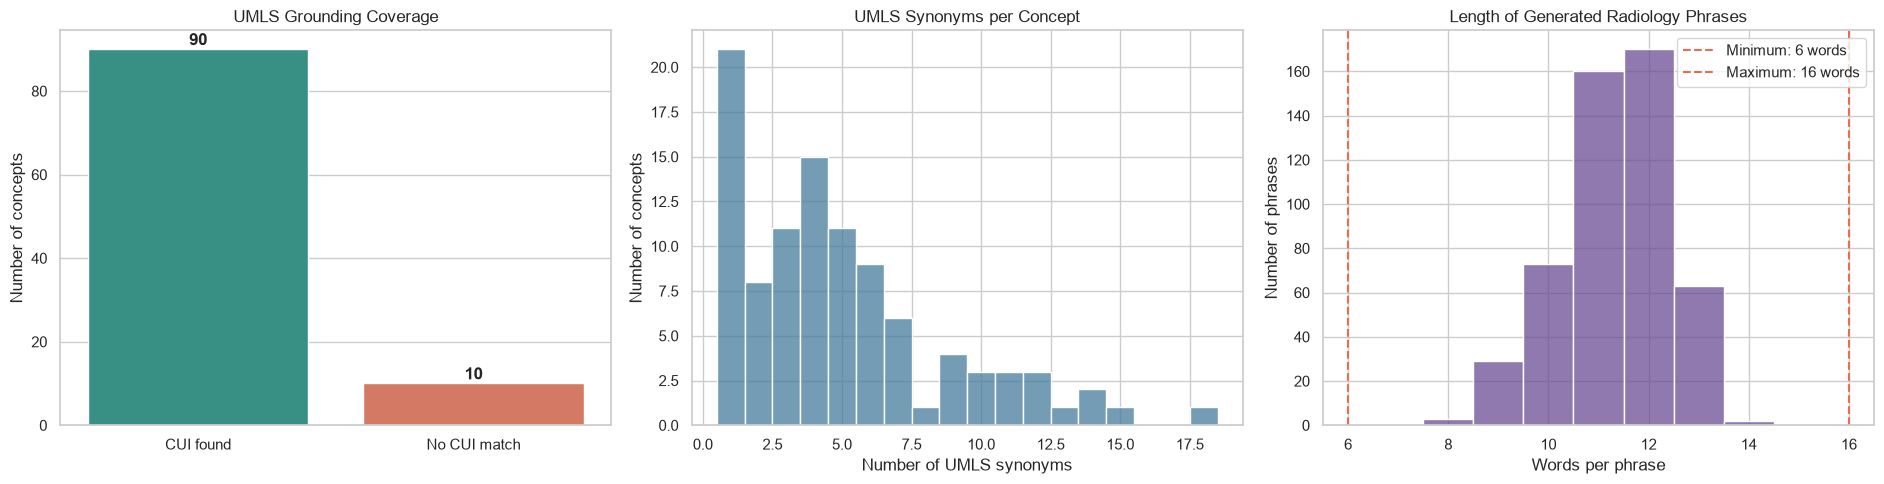

In [59]:
# Load the structured LLM-expanded dictionary
llm_checkpoint_path = os.path.join(save_dir, "llm_checkpoint.json")

if not os.path.exists(llm_checkpoint_path):
    raise FileNotFoundError(
        f"LLM checkpoint not found at:\n{llm_checkpoint_path}"
    )

with open(llm_checkpoint_path, "r", encoding="utf-8") as f:
    expanded_dictionary_dict = json.load(f)

print(f"Loaded LLM-expanded dictionary with {len(expanded_dictionary_dict)} concepts.")

# Build a concept-level audit table
def word_count(text):
    return len(str(text).split())

audit_rows = []

for label, entry in expanded_dictionary_dict.items():
    umls_synonyms = entry.get("umls_synonyms", [])
    llm_sentences = entry.get("llm_generated_sentences", [])

    sentence_word_counts = [word_count(sentence) for sentence in llm_sentences]
    sentence_char_counts = [len(sentence) for sentence in llm_sentences]

    audit_rows.append({
        "concept": label,
        "cui": entry.get("cui"),
        "umls_status": entry.get("umls_status"),
        "llm_status": entry.get("llm_status"),
        "n_umls_synonyms": len(umls_synonyms),
        "n_llm_sentences": len(llm_sentences),
        "mean_sentence_words": (
            round(sum(sentence_word_counts) / len(sentence_word_counts), 2)
            if sentence_word_counts else 0
        ),
        "min_sentence_words": min(sentence_word_counts, default=0),
        "max_sentence_words": max(sentence_word_counts, default=0),
        "mean_sentence_characters": (
            round(sum(sentence_char_counts) / len(sentence_char_counts), 2)
            if sentence_char_counts else 0
        ),
        "all_sentences_valid": len(llm_sentences) == 5,
        "umls_synonyms": " | ".join(umls_synonyms),
        "llm_generated_sentences": " | ".join(llm_sentences),
        "error": entry.get("error")
    })

audit_df = pd.DataFrame(audit_rows)

# Print key quality-control statistics
n_concepts = len(audit_df)
n_successful = (audit_df["llm_status"] == "ok").sum()
n_failed = (audit_df["llm_status"] == "failed").sum()
n_with_cui = audit_df["cui"].notna().sum()
n_without_cui = audit_df["cui"].isna().sum()
n_valid_five = audit_df["all_sentences_valid"].sum()

print("\n--- Dictionary Expansion Summary ---")
print(f"Total concepts:                  {n_concepts}")
print(f"LLM generation successful:       {n_successful}")
print(f"LLM generation failed:           {n_failed}")
print(f"Concepts with a UMLS CUI:        {n_with_cui}")
print(f"Concepts without a UMLS CUI:     {n_without_cui}")
print(f"Entries with exactly 5 phrases:  {n_valid_five}")
print(
    "Mean UMLS synonyms per concept: "
    f"{audit_df['n_umls_synonyms'].mean():.2f}"
)
print(
    "Mean words per LLM phrase:      "
    f"{audit_df['mean_sentence_words'].mean():.2f}"
)

# Visualize dictionary composition and phrase quality
sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# 1. UMLS grounding coverage
grounding_counts = pd.Series({
    "CUI found": n_with_cui,
    "No CUI match": n_without_cui
})

sns.barplot(
    x=grounding_counts.index,
    y=grounding_counts.values,
    hue=grounding_counts.index,
    palette=["#2A9D8F", "#E76F51"],
    legend=False,
    ax=axes[0],
    dodge=False,
)
axes[0].set_title("UMLS Grounding Coverage")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of concepts")

for index, value in enumerate(grounding_counts.values):
    axes[0].text(index, value + 1, str(value), ha="center", fontweight="bold")

# 2. Number of UMLS synonyms
sns.histplot(
    data=audit_df,
    x="n_umls_synonyms",
    bins=range(
        0,
        int(audit_df["n_umls_synonyms"].max()) + 2
    ),
    discrete=True,
    color="#457B9D",
    ax=axes[1]
)
axes[1].set_title("UMLS Synonyms per Concept")
axes[1].set_xlabel("Number of UMLS synonyms")
axes[1].set_ylabel("Number of concepts")

# 3. Generated phrase length
all_generated_word_counts = []

for entry in expanded_dictionary_dict.values():
    for sentence in entry.get("llm_generated_sentences", []):
        all_generated_word_counts.append(word_count(sentence))

sns.histplot(
    all_generated_word_counts,
    bins=range(0, max(all_generated_word_counts) + 2),
    discrete=True,
    color="#6A4C93",
    ax=axes[2]
)
axes[2].axvline(
    6,
    color="#E76F51",
    linestyle="--",
    linewidth=1.5,
    label="Minimum: 6 words"
)
axes[2].axvline(
    16,
    color="#E76F51",
    linestyle="--",
    linewidth=1.5,
    label="Maximum: 16 words"
)
axes[2].set_title("Length of Generated Radiology Phrases")
axes[2].set_xlabel("Words per phrase")
axes[2].set_ylabel("Number of phrases")
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Encoding and Exporting the T Matrix

We convert the finalized textual dictionary into a phrase-level semantic matrix \(T\) using the BioMedCLIP text encoder. Each UMLS synonym and each LLM-generated radiology phrase is embedded independently, preserving both the clinically standardized terminology and the visually descriptive language generated for chest X-ray findings.

Every row of \(T\) is L2-normalized and linked to its parent clinical concept, CUI, and source type (`umls_synonym` or `llm_radiology_phrase`) through an accompanying metadata file. In the next stage, the 1,024 SAE decoder features will be compared against all phrase embeddings using cosine similarity; scores can then be aggregated by parent concept while retaining the exact phrase that provided the strongest semantic match.

In [62]:
# Configuration
BIOCLIP_MODEL_NAME = ("hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224")
BATCH_SIZE = 32

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# Load BioMedCLIP and encode every text item independently
print("\nLoading BioMedCLIP text encoder...")
model, _ = open_clip.create_model_from_pretrained(BIOCLIP_MODEL_NAME)
tokenizer = open_clip.get_tokenizer(BIOCLIP_MODEL_NAME)

model = model.to(device)
model.eval()

Using device: mps

Loading BioMedCLIP text encoder...


CustomTextCLIP(
  (visual): TimmModel(
    (trunk): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          (attn): Attention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          

In [63]:
@torch.inference_mode()
def encode_texts(texts, batch_size=BATCH_SIZE):
    all_embeddings = []

    for start in tqdm(
        range(0, len(texts), batch_size),
        desc="Encoding text",
        leave=False
    ):
        batch_texts = texts[start:start + batch_size]
        tokens = tokenizer(batch_texts).to(device)

        embeddings = model.encode_text(tokens)

        # Every matrix row is a unit vector: dot product = cosine similarity.
        embeddings = F.normalize(embeddings, p=2, dim=1)

        all_embeddings.append(embeddings.cpu())

    return torch.cat(all_embeddings, dim=0)

In [64]:
# Load the completed dictionary
llm_checkpoint_path = os.path.join(save_dir, "llm_checkpoint.json")

with open(llm_checkpoint_path, "r", encoding="utf-8") as f:
    expanded_dictionary_dict = json.load(f)

valid_entries = {
    concept: entry
    for concept, entry in expanded_dictionary_dict.items()
    if (entry.get("llm_status") == "ok" and len(entry.get("llm_generated_sentences", [])) == 5 and len(entry.get("umls_synonyms", [])) > 0)
}

if len(valid_entries) == 0:
    raise RuntimeError("No valid concept entries available for text encoding.")

print(f"Encoding text for {len(valid_entries)} concepts.")

# Convert each synonym and each LLM phrase into one matrix row
phrase_records = []
seen_records = set()

for concept, entry in valid_entries.items():
    text_groups = {
        "umls_synonym": entry["umls_synonyms"],
        "llm_radiology_phrase": entry["llm_generated_sentences"]
    }

    for text_source, texts in text_groups.items():
        for text in texts:
            cleaned_text = str(text).strip().lower()

            # Avoid duplicate rows only within the same parent concept.
            record_key = (concept, cleaned_text)

            if cleaned_text and record_key not in seen_records:
                phrase_records.append({
                    "parent_concept": concept,
                    "text": cleaned_text,
                    "text_source": text_source,
                    "cui": entry.get("cui"),
                    "umls_status": entry.get("umls_status")
                })
                seen_records.add(record_key)

phrase_metadata = pd.DataFrame(phrase_records)

if phrase_metadata.empty:
    raise RuntimeError("No text phrases were constructed.")

phrase_texts = phrase_metadata["text"].tolist()

print(f"Total independent text rows: {len(phrase_metadata)}")
display(
    phrase_metadata["text_source"]
    .value_counts()
    .rename_axis("source")
    .reset_index(name="n_rows")
)

# T_phrases: [number_of_text_rows, BioMedCLIP_embedding_dimension]
T_phrases = encode_texts(phrase_texts)
print(f"\nT_phrases shape: {tuple(T_phrases.shape)}")

# Save phrase-level matrix and its row mapping
phrase_metadata = phrase_metadata.reset_index(names="phrase_index")

matrix_path = os.path.join(save_dir, "biomedclip_phrase_level_concept_matrix.pt")
metadata_path = os.path.join(save_dir, "biomedclip_phrase_level_metadata.csv")

torch.save(T_phrases, matrix_path)
phrase_metadata.to_csv(metadata_path, index=False, encoding="utf-8")

print(f"Saved T_phrases: {T_phrases.shape}")
print(f"Matrix:   {matrix_path}")
print(f"Metadata: {metadata_path}")

Encoding text for 100 concepts.
Total independent text rows: 998


,source,n_rows
0,llm_radiology_phrase,500
1,umls_synonym,498


Encoding text:   0%|          | 0/32 [00:00<?, ?it/s]


T_phrases shape: (998, 512)
Saved T_phrases: torch.Size([998, 512])
Matrix:   /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/02_dictionary_creation/biomedclip_phrase_level_concept_matrix.pt
Metadata: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/02_dictionary_creation/biomedclip_phrase_level_metadata.csv
